In [41]:
import os
import sys
import torch
import yaml
import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image

# Add parent directory to path
sys.path.append(os.path.dirname(os.path.abspath('.')))

from detector_cartoon import DetectorCartoon

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.9.1+cu128
CUDA available: True
CUDA device: NVIDIA A100-SXM4-80GB


## Configuration

Set paths for models and test samples:

In [42]:
# Configuration paths
BASE_DIR = Path("/home/serverai/ltdoanh/LayoutGeneration")
OBJECTFREE_DIR = BASE_DIR / "objectfree"

# Model paths
TRAINED_MODEL_PATH = OBJECTFREE_DIR / "weight_model/yoloe/weights/best_general.pt"
UNTRAINED_MODEL_PATH = OBJECTFREE_DIR / "yoloe/yoloe-v8l-seg-det.pt"  # Base model

PE_PATH = OBJECTFREE_DIR / "weight_model/character-pe.pt"

# Test samples
SAMPLE_DIR = BASE_DIR / "/home/serverai/ltdoanh/LayoutGeneration/data/samples/keyframe4check/31957_keyframes"
OUTPUT_DIR = BASE_DIR / "outputs/inference_comparison_test2_0.3"

# Create output directory
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Detection parameters
THRESHOLD = 0.3
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"✓ Base directory: {BASE_DIR}")
print(f"✓ Trained model exists: {TRAINED_MODEL_PATH.exists()}")
print(f"✓ Untrained model exists: {UNTRAINED_MODEL_PATH.exists()}")
print(f"✓ PE embeddings exist: {PE_PATH.exists()}")
print(f"✓ Sample directory exists: {SAMPLE_DIR.exists()}")
print(f"✓ Output directory: {OUTPUT_DIR}")

✓ Base directory: /home/serverai/ltdoanh/LayoutGeneration
✓ Trained model exists: True
✓ Untrained model exists: True
✓ PE embeddings exist: True
✓ Sample directory exists: True
✓ Output directory: /home/serverai/ltdoanh/LayoutGeneration/outputs/inference_comparison_test2_0.3


## Download Untrained (Base) Model

If the untrained model doesn't exist, download it from Ultralytics and convert from segmentation to detection:

In [43]:
# Verify the model exists now
print("\nModel Status Check:")
print(f"✓ Trained model exists: {TRAINED_MODEL_PATH.exists()}")
print(f"✓ Untrained model exists: {UNTRAINED_MODEL_PATH.exists()}")

if UNTRAINED_MODEL_PATH.exists():
    # Check model size
    model_size_mb = UNTRAINED_MODEL_PATH.stat().st_size / (1024 * 1024)
    print(f"✓ Untrained model size: {model_size_mb:.2f} MB")
    
    # Try to load and inspect the model
    try:
        test_model = YOLO(str(UNTRAINED_MODEL_PATH))
        print(f"✓ Model task: {test_model.task}")
        print(f"✓ Model type: {test_model.model_name if hasattr(test_model, 'model_name') else 'YOLO'}")
        print("\n✅ Untrained model is ready for use!")
    except Exception as e:
        print(f"⚠️  Warning: Could not fully validate model: {e}")
else:
    print("❌ Untrained model still not available. Please check the download process.")


Model Status Check:
✓ Trained model exists: True
✓ Untrained model exists: True
✓ Untrained model size: 102.43 MB
⚠️  Warning: Could not fully validate model: name 'YOLO' is not defined


### Alternative: Direct YOLO Detection Model Download

If you prefer to use a pure detection model (not converted from segmentation), uncomment and run this cell:

## Load Models

Initialize both trained and untrained detectors:

In [44]:
# Create temporary config files for both models
config_trained = {
    'model_path': str(TRAINED_MODEL_PATH),
    'input_path': str(SAMPLE_DIR),
    'threshold': THRESHOLD,
    'prompt': 'characters ',
    'save_path': str(OUTPUT_DIR / "trained"),
    'type_content': 'image',
    'device': DEVICE,
    'pe_path': str(PE_PATH)
}

config_untrained = {
    'model_path': str(UNTRAINED_MODEL_PATH),
    'input_path': str(SAMPLE_DIR),
    'threshold': THRESHOLD,
    'prompt': 'characters ',
    'save_path': str(OUTPUT_DIR / "untrained"),
    'type_content': 'image',
    'device': DEVICE,
    'pe_path': str(PE_PATH)
}

# Save temporary configs
config_trained_path = OBJECTFREE_DIR / "temp_config_trained.yaml"
config_untrained_path = OBJECTFREE_DIR / "temp_config_untrained.yaml"

with open(config_trained_path, 'w') as f:
    yaml.dump(config_trained, f)
    
with open(config_untrained_path, 'w') as f:
    yaml.dump(config_untrained, f)

print("✓ Configuration files created")

✓ Configuration files created


In [45]:
# Initialize detectors
print("Loading TRAINED model...")
detector_trained = DetectorCartoon(config_path=str(config_trained_path))
print("✓ Trained model loaded\n")

print("Loading UNTRAINED model...")
detector_untrained = DetectorCartoon(config_path=str(config_untrained_path))
print("✓ Untrained model loaded")

Loading TRAINED model...
Loading model on device: cuda


Loaded 82 character classes, using first one for detection
✓ Trained model loaded

Loading UNTRAINED model...
Loading model on device: cuda
Loaded 82 character classes, using first one for detection
✓ Untrained model loaded
Loaded 82 character classes, using first one for detection
✓ Untrained model loaded


## Select Test Samples

Choose a few sample images to test:

In [46]:
# Get sample images
sample_images = sorted([f for f in os.listdir(SAMPLE_DIR) if f.endswith(('.jpg', '.png', '.jpeg'))])

# Select first N samples for testing
NUM_SAMPLES = 5
test_samples = sample_images[:NUM_SAMPLES]

print(f"Total images available: {len(sample_images)}")
print(f"Testing on {len(test_samples)} samples:")
for i, img in enumerate(test_samples, 1):
    print(f"  {i}. {img}")

Total images available: 10
Testing on 5 samples:
  1. 0000_clip03_frame168_31957_3.jpg
  2. 0001_clip04_frame082_31957_4.jpg
  3. 0002_clip05_frame132_31957_5.jpg
  4. 0003_clip06_frame079_31957_6.jpg
  5. 0004_clip08_frame153_31957_8.jpg


## Run Inference

Run detection on both trained and untrained models:

In [47]:
# Prepare test image paths
test_image_paths = [str(SAMPLE_DIR / img) for img in test_samples]

print("=" * 60)
print("RUNNING INFERENCE ON TRAINED MODEL")
print("=" * 60)
results_trained = detector_trained._predict_batch(
    image_paths=test_image_paths,
    save_dir=None,  # Don't save, we'll visualize
    max_images=NUM_SAMPLES
)

print("\n" + "=" * 60)
print("RUNNING INFERENCE ON UNTRAINED MODEL")
print("=" * 60)
results_untrained = detector_untrained._predict_batch(
    image_paths=test_image_paths,
    save_dir=None,
    max_images=NUM_SAMPLES
)

print("\n✓ Inference completed on both models")

RUNNING INFERENCE ON TRAINED MODEL


Processing images:   0%|          | 0/5 [00:00<?, ?it/s]


0: 640x640 1 character, 17.4ms
1: 640x640 1 character, 17.4ms
2: 640x640 3 characters, 17.4ms
3: 640x640 1 character, 17.4ms
4: 640x640 (no detections), 17.4ms
0: 640x640 1 character, 17.4ms
1: 640x640 1 character, 17.4ms
2: 640x640 3 characters, 17.4ms
3: 640x640 1 character, 17.4ms
4: 640x640 (no detections), 17.4ms


Processing images:  20%|██        | 1/5 [00:00<00:01,  3.17it/s]

Speed: 2.1ms preprocess, 17.4ms inference, 16.2ms postprocess per image at shape (1, 3, 640, 640)


...


0: 640x640 (no detections), 10.7ms
1: 640x640 (no detections), 10.7ms
2: 640x640 (no detections), 10.7ms
3: 640x640 (no detections), 10.7ms
4: 640x640 (no detections), 10.7ms
0: 640x640 (no detections), 10.7ms
1: 640x640 (no detections), 10.7ms
2: 640x640 (no detections), 10.7ms
3: 640x640 (no detections), 10.7ms
4: 640x640 (no detections), 10.7ms


Processing images:  20%|██        | 1/5 [00:00<00:00,  5.88it/s]

Speed: 1.7ms preprocess, 10.7ms inference, 5.9ms postprocess per image at shape (1, 3, 640, 640)


Processing images: 100%|██████████| 5/5 [00:00<00:00, 29.11it/s]


✓ Inference completed on both models


## Compare Results

Print detection statistics:

In [48]:
# Compare detection counts
print("DETECTION STATISTICS")
print("=" * 80)
print(f"{'Image':<40} {'Trained':<15} {'Untrained':<15} {'Difference'}")
print("=" * 80)

for i, (img_name, res_trained, res_untrained) in enumerate(zip(test_samples, results_trained, results_untrained)):
    count_trained = len(res_trained.boxes) if hasattr(res_trained, 'boxes') else 0
    count_untrained = len(res_untrained.boxes) if hasattr(res_untrained, 'boxes') else 0
    diff = count_trained - count_untrained
    
    print(f"{img_name:<40} {count_trained:<15} {count_untrained:<15} {diff:+d}")

print("=" * 80)
total_trained = sum(len(r.boxes) if hasattr(r, 'boxes') else 0 for r in results_trained)
total_untrained = sum(len(r.boxes) if hasattr(r, 'boxes') else 0 for r in results_untrained)
print(f"{'TOTAL':<40} {total_trained:<15} {total_untrained:<15} {total_trained - total_untrained:+d}")
print("=" * 80)

DETECTION STATISTICS
Image                                    Trained         Untrained       Difference
0000_clip03_frame168_31957_3.jpg         1               0               +1
0001_clip04_frame082_31957_4.jpg         1               0               +1
0002_clip05_frame132_31957_5.jpg         3               0               +3
0003_clip06_frame079_31957_6.jpg         1               0               +1
0004_clip08_frame153_31957_8.jpg         0               0               +0
TOTAL                                    6               0               +6


## Visualize Results

Compare detections side by side:

In [49]:
def visualize_detections(image_path, result, title):
    """Visualize detection results on an image"""
    # Read image
    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Draw bounding boxes
    if hasattr(result, 'boxes') and len(result.boxes) > 0:
        for box in result.boxes:
            # Get box coordinates
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
            conf = box.conf[0].cpu().numpy()
            
            # Draw rectangle
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
            
            # Draw confidence score
            label = f"{conf:.2f}"
            cv2.putText(img, label, (x1, y1 - 10), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    
    # Plot
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.title(f"{title}\nDetections: {len(result.boxes) if hasattr(result, 'boxes') else 0}", 
             fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    
    return img


Sample 1/5: 0000_clip03_frame168_31957_3.jpg


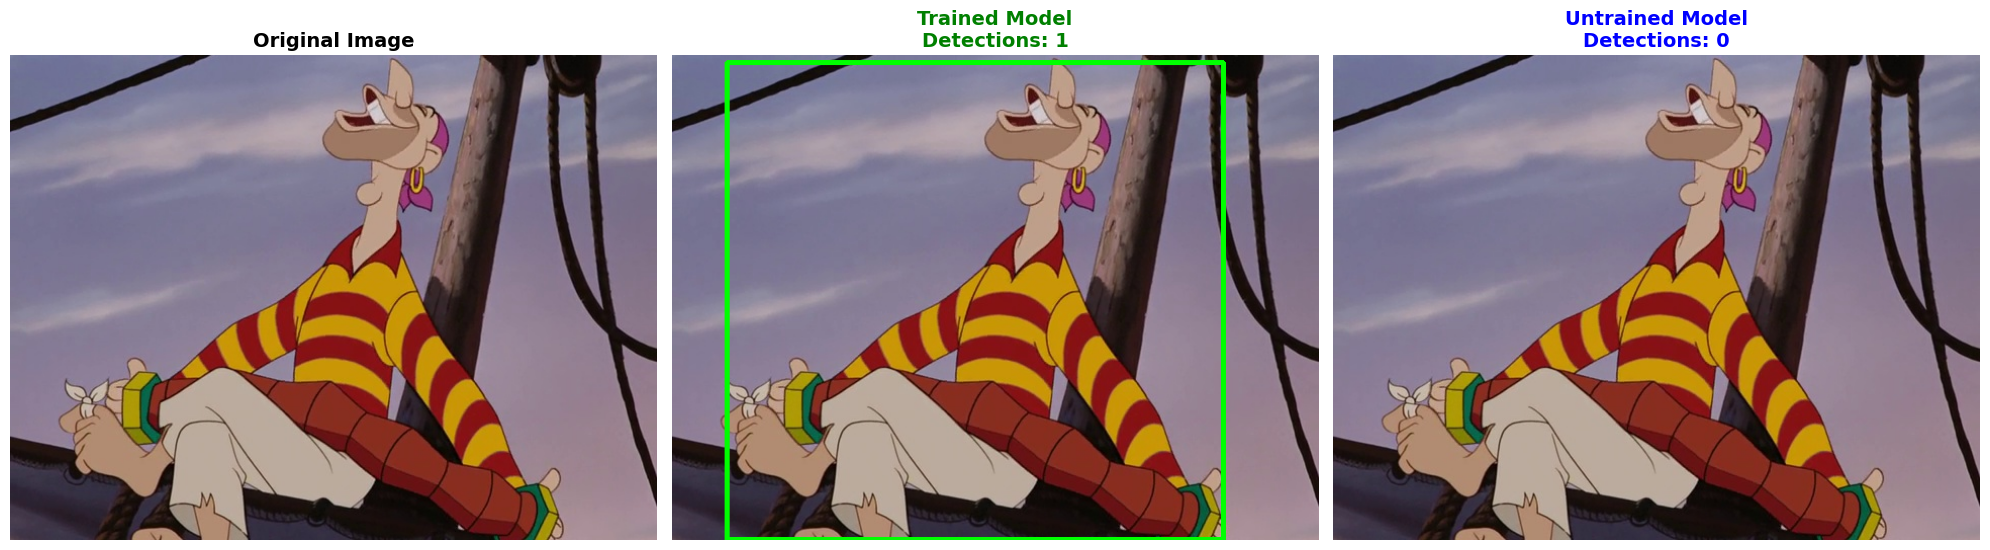

✓ Saved comparison to: /home/serverai/ltdoanh/LayoutGeneration/outputs/inference_comparison_test2_0.3/comparison_1_0000_clip03_frame168_31957_3.jpg

Sample 2/5: 0001_clip04_frame082_31957_4.jpg


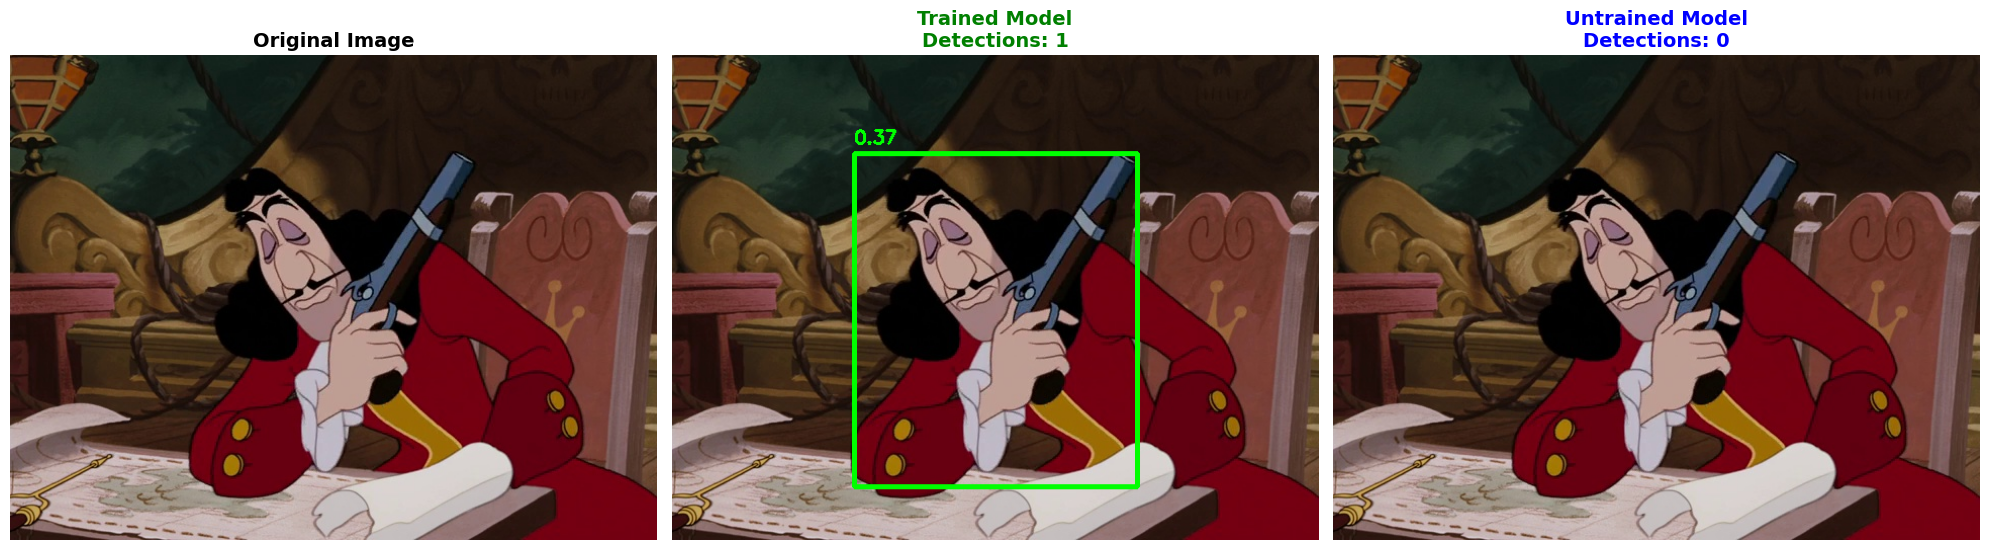

✓ Saved comparison to: /home/serverai/ltdoanh/LayoutGeneration/outputs/inference_comparison_test2_0.3/comparison_2_0001_clip04_frame082_31957_4.jpg

Sample 3/5: 0002_clip05_frame132_31957_5.jpg


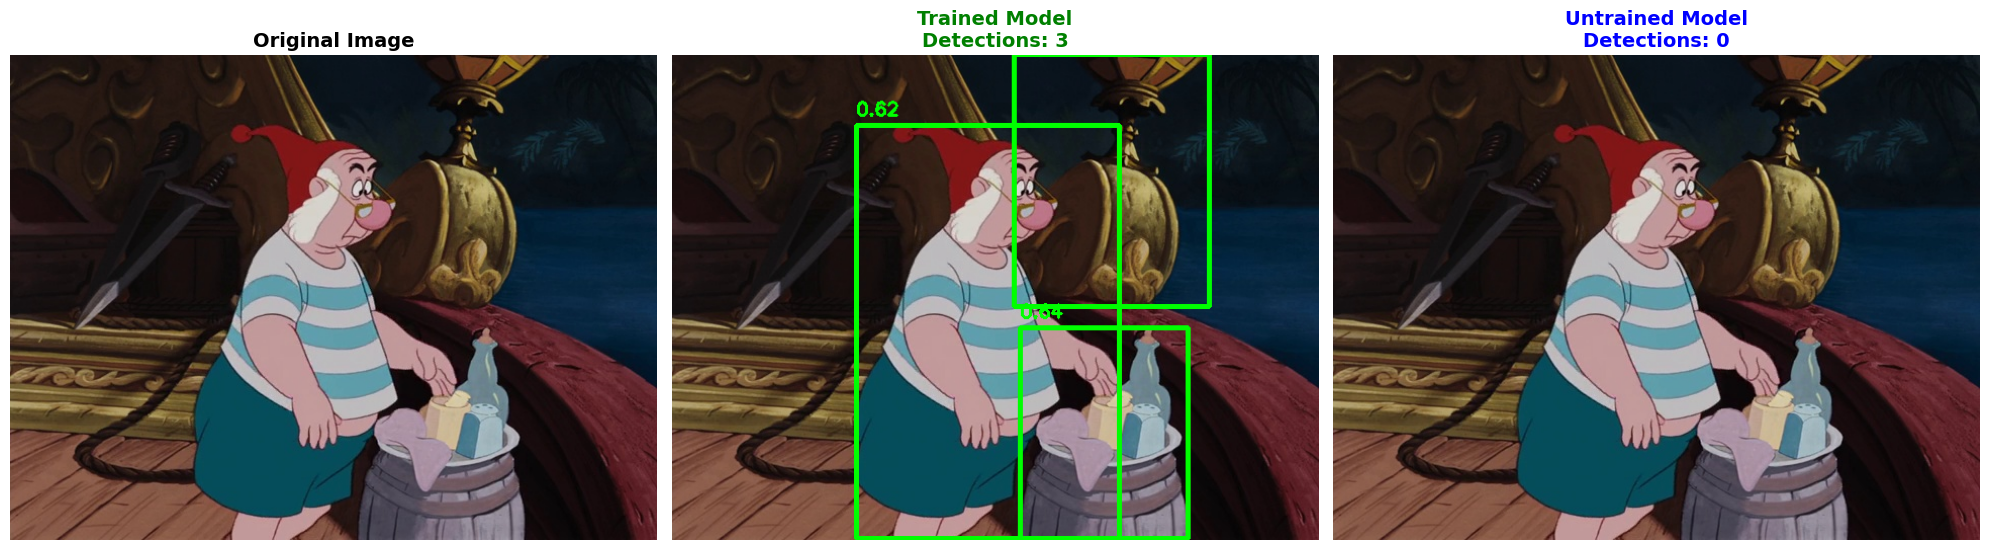

✓ Saved comparison to: /home/serverai/ltdoanh/LayoutGeneration/outputs/inference_comparison_test2_0.3/comparison_3_0002_clip05_frame132_31957_5.jpg

Sample 4/5: 0003_clip06_frame079_31957_6.jpg


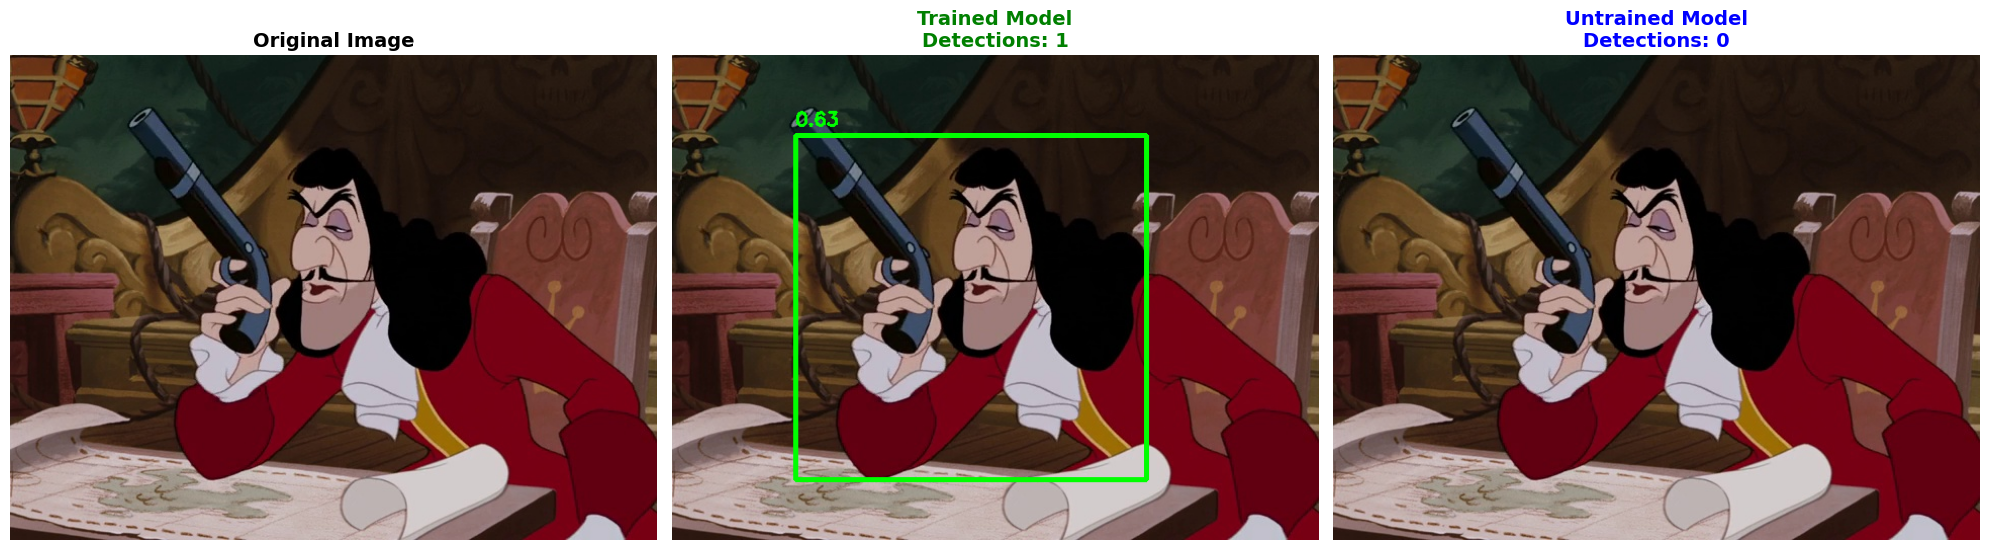

✓ Saved comparison to: /home/serverai/ltdoanh/LayoutGeneration/outputs/inference_comparison_test2_0.3/comparison_4_0003_clip06_frame079_31957_6.jpg

Sample 5/5: 0004_clip08_frame153_31957_8.jpg


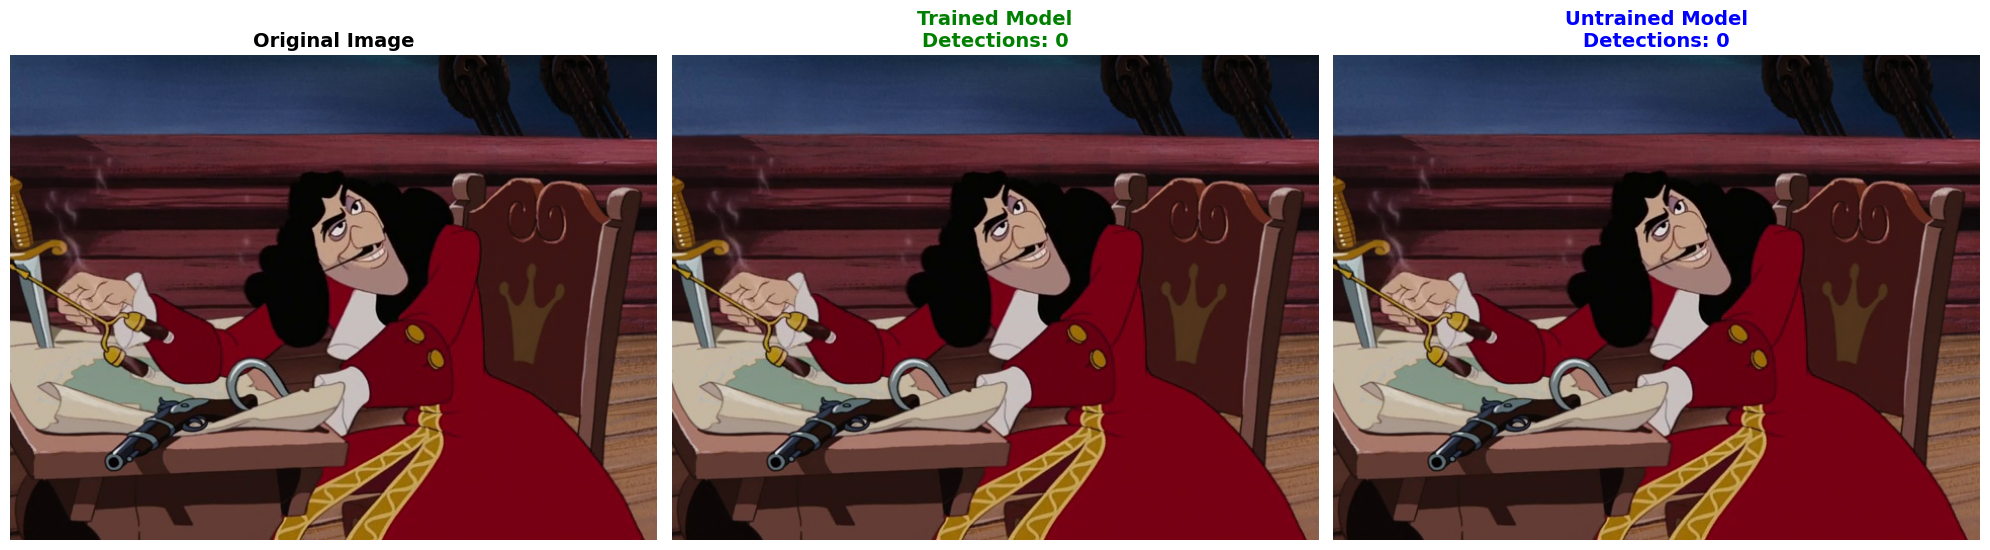

✓ Saved comparison to: /home/serverai/ltdoanh/LayoutGeneration/outputs/inference_comparison_test2_0.3/comparison_5_0004_clip08_frame153_31957_8.jpg


In [50]:
# Visualize each sample - side by side comparison
for i, (img_path, res_trained, res_untrained) in enumerate(zip(test_image_paths, results_trained, results_untrained)):
    img_name = Path(img_path).name
    
    print(f"\n{'='*80}")
    print(f"Sample {i+1}/{NUM_SAMPLES}: {img_name}")
    print(f"{'='*80}")
    
    # Create side-by-side comparison
    fig, axes = plt.subplots(1, 3, figsize=(20, 7))
    
    # Original image
    img_original = cv2.imread(img_path)
    img_original = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)
    axes[0].imshow(img_original)
    axes[0].set_title('Original Image', fontsize=14, fontweight='bold')
    axes[0].axis('off')
    
    # Trained model
    img_trained = img_original.copy()
    if hasattr(res_trained, 'boxes') and len(res_trained.boxes) > 0:
        for box in res_trained.boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
            conf = box.conf[0].cpu().numpy()
            cv2.rectangle(img_trained, (x1, y1), (x2, y2), (0, 255, 0), 3)
            cv2.putText(img_trained, f"{conf:.2f}", (x1, y1 - 10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    
    axes[1].imshow(img_trained)
    axes[1].set_title(f'Trained Model\nDetections: {len(res_trained.boxes) if hasattr(res_trained, "boxes") else 0}',
                     fontsize=14, fontweight='bold', color='green')
    axes[1].axis('off')
    
    # Untrained model
    img_untrained = img_original.copy()
    if hasattr(res_untrained, 'boxes') and len(res_untrained.boxes) > 0:
        for box in res_untrained.boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
            conf = box.conf[0].cpu().numpy()
            cv2.rectangle(img_untrained, (x1, y1), (x2, y2), (255, 0, 0), 3)
            cv2.putText(img_untrained, f"{conf:.2f}", (x1, y1 - 10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
    
    axes[2].imshow(img_untrained)
    axes[2].set_title(f'Untrained Model\nDetections: {len(res_untrained.boxes) if hasattr(res_untrained, "boxes") else 0}',
                     fontsize=14, fontweight='bold', color='blue')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"comparison_{i+1}_{img_name}", dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"✓ Saved comparison to: {OUTPUT_DIR / f'comparison_{i+1}_{img_name}'}")

## Detailed Detection Analysis

Show confidence scores and bounding box coordinates:

In [51]:
# Detailed analysis for each image
for i, (img_name, res_trained, res_untrained) in enumerate(zip(test_samples, results_trained, results_untrained)):
    print(f"\n{'='*80}")
    print(f"IMAGE {i+1}: {img_name}")
    print(f"{'='*80}")
    
    # Trained model detections
    print(f"\n📊 TRAINED MODEL - {len(res_trained.boxes) if hasattr(res_trained, 'boxes') else 0} detections:")
    if hasattr(res_trained, 'boxes') and len(res_trained.boxes) > 0:
        for j, box in enumerate(res_trained.boxes, 1):
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            conf = box.conf[0].cpu().numpy()
            w, h = x2 - x1, y2 - y1
            print(f"  Detection {j}: confidence={conf:.3f}, bbox=[{x1:.0f}, {y1:.0f}, {x2:.0f}, {y2:.0f}], size={w:.0f}x{h:.0f}")
    else:
        print("  No detections")
    
    # Untrained model detections
    print(f"\n📊 UNTRAINED MODEL - {len(res_untrained.boxes) if hasattr(res_untrained, 'boxes') else 0} detections:")
    if hasattr(res_untrained, 'boxes') and len(res_untrained.boxes) > 0:
        for j, box in enumerate(res_untrained.boxes, 1):
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            conf = box.conf[0].cpu().numpy()
            w, h = x2 - x1, y2 - y1
            print(f"  Detection {j}: confidence={conf:.3f}, bbox=[{x1:.0f}, {y1:.0f}, {x2:.0f}, {y2:.0f}], size={w:.0f}x{h:.0f}")
    else:
        print("  No detections")


IMAGE 1: 0000_clip03_frame168_31957_3.jpg

📊 TRAINED MODEL - 1 detections:
  Detection 1: confidence=0.736, bbox=[54, 8, 546, 479], size=491x471

📊 UNTRAINED MODEL - 0 detections:
  No detections

IMAGE 2: 0001_clip04_frame082_31957_4.jpg

📊 TRAINED MODEL - 1 detections:
  Detection 1: confidence=0.375, bbox=[180, 98, 460, 427], size=280x329

📊 UNTRAINED MODEL - 0 detections:
  No detections

IMAGE 3: 0002_clip05_frame132_31957_5.jpg

📊 TRAINED MODEL - 3 detections:
  Detection 1: confidence=0.644, bbox=[345, 271, 510, 478], size=165x208
  Detection 2: confidence=0.617, bbox=[182, 70, 442, 478], size=260x408
  Detection 3: confidence=0.329, bbox=[339, 0, 531, 249], size=192x249

📊 UNTRAINED MODEL - 0 detections:
  No detections

IMAGE 4: 0003_clip06_frame079_31957_6.jpg

📊 TRAINED MODEL - 1 detections:
  Detection 1: confidence=0.632, bbox=[123, 80, 470, 420], size=347x340

📊 UNTRAINED MODEL - 0 detections:
  No detections

IMAGE 5: 0004_clip08_frame153_31957_8.jpg

📊 TRAINED MODEL - 

## Summary

Final comparison summary:


FINAL SUMMARY
Tested on 5 images from: 31957_keyframes

📈 TRAINED MODEL:
  - Total detections: 6
  - Average detections per image: 1.20
  - Average confidence: 0.555 (±0.149)
  - Min/Max confidence: 0.329 / 0.736

📉 UNTRAINED MODEL:
  - Total detections: 0
  - Average detections per image: 0.00
  - No detections made

💾 All comparison images saved to: /home/serverai/ltdoanh/LayoutGeneration/outputs/inference_comparison_test2_0.3


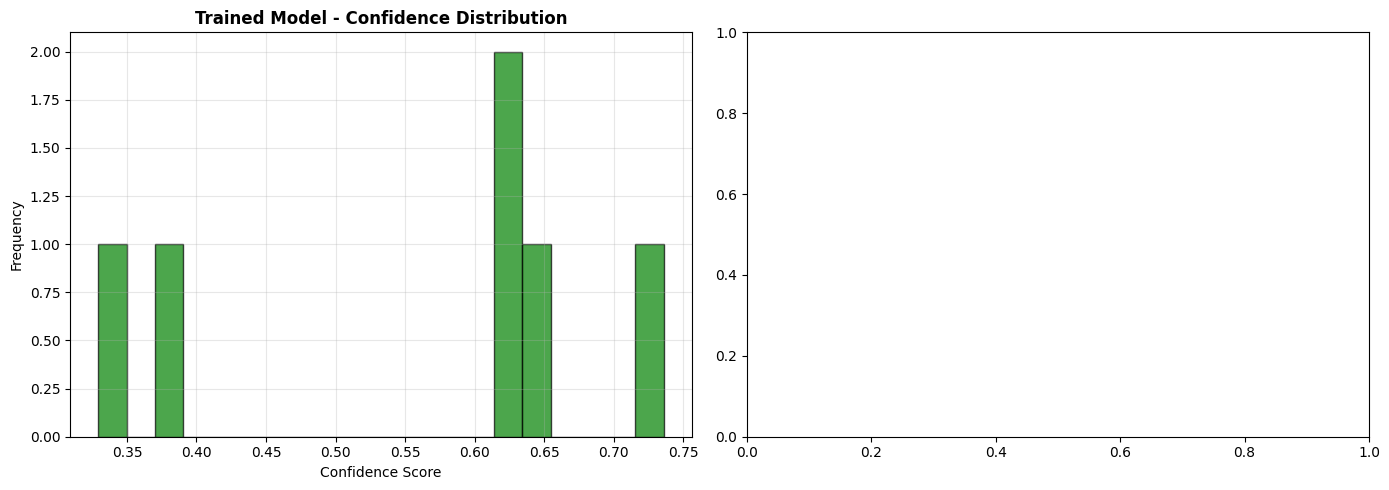

✓ Confidence distribution saved to: /home/serverai/ltdoanh/LayoutGeneration/outputs/inference_comparison_test2_0.3/confidence_distribution.png


In [52]:
# Calculate average confidence scores
avg_conf_trained = []
avg_conf_untrained = []

for res_trained, res_untrained in zip(results_trained, results_untrained):
    if hasattr(res_trained, 'boxes') and len(res_trained.boxes) > 0:
        confs = [box.conf[0].cpu().numpy() for box in res_trained.boxes]
        avg_conf_trained.extend(confs)
    
    if hasattr(res_untrained, 'boxes') and len(res_untrained.boxes) > 0:
        confs = [box.conf[0].cpu().numpy() for box in res_untrained.boxes]
        avg_conf_untrained.extend(confs)

print("\n" + "="*80)
print("FINAL SUMMARY")
print("="*80)
print(f"Tested on {NUM_SAMPLES} images from: {SAMPLE_DIR.name}")
print(f"\n📈 TRAINED MODEL:")
print(f"  - Total detections: {total_trained}")
print(f"  - Average detections per image: {total_trained/NUM_SAMPLES:.2f}")
if avg_conf_trained:
    print(f"  - Average confidence: {np.mean(avg_conf_trained):.3f} (±{np.std(avg_conf_trained):.3f})")
    print(f"  - Min/Max confidence: {np.min(avg_conf_trained):.3f} / {np.max(avg_conf_trained):.3f}")
else:
    print(f"  - No detections made")

print(f"\n📉 UNTRAINED MODEL:")
print(f"  - Total detections: {total_untrained}")
print(f"  - Average detections per image: {total_untrained/NUM_SAMPLES:.2f}")
if avg_conf_untrained:
    print(f"  - Average confidence: {np.mean(avg_conf_untrained):.3f} (±{np.std(avg_conf_untrained):.3f})")
    print(f"  - Min/Max confidence: {np.min(avg_conf_untrained):.3f} / {np.max(avg_conf_untrained):.3f}")
else:
    print(f"  - No detections made")

print(f"\n💾 All comparison images saved to: {OUTPUT_DIR}")
print("="*80)

# Confidence distribution comparison
if avg_conf_trained or avg_conf_untrained:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    if avg_conf_trained:
        axes[0].hist(avg_conf_trained, bins=20, color='green', alpha=0.7, edgecolor='black')
        axes[0].set_title('Trained Model - Confidence Distribution', fontsize=12, fontweight='bold')
        axes[0].set_xlabel('Confidence Score')
        axes[0].set_ylabel('Frequency')
        axes[0].grid(True, alpha=0.3)
    
    if avg_conf_untrained:
        axes[1].hist(avg_conf_untrained, bins=20, color='blue', alpha=0.7, edgecolor='black')
        axes[1].set_title('Untrained Model - Confidence Distribution', fontsize=12, fontweight='bold')
        axes[1].set_xlabel('Confidence Score')
        axes[1].set_ylabel('Frequency')
        axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'confidence_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Confidence distribution saved to: {OUTPUT_DIR / 'confidence_distribution.png'}")

## Cleanup

Remove temporary configuration files:

In [53]:
# Clean up temporary config files
if config_trained_path.exists():
    os.remove(config_trained_path)
    print(f"✓ Removed {config_trained_path}")

if config_untrained_path.exists():
    os.remove(config_untrained_path)
    print(f"✓ Removed {config_untrained_path}")

print("\n✅ Inference comparison completed successfully!")

✓ Removed /home/serverai/ltdoanh/LayoutGeneration/objectfree/temp_config_trained.yaml
✓ Removed /home/serverai/ltdoanh/LayoutGeneration/objectfree/temp_config_untrained.yaml

✅ Inference comparison completed successfully!
